In this notebook, a recurrent model was trained to forecast ATP player rankings one month ahead, documenting every adjustment so I can reproduce the 2024 evaluation window on GitHub or Colab.

In [1]:
# --- User configuration --------------------------------------------------
use_sample_data = False      # False downloads Jeff Sackmann's full ATP dataset
sequence_length = 8         # number of ranking observations per training window
forecast_horizon = 1        # predict one step (~4 weeks) ahead
test_year = 2024            # hold-out year; training uses strictly earlier seasons
match_year_start = 2000     # only use matches/rankings from this year onward
hidden_size = 64            # LSTM hidden units
epochs = 15                 # keep compact for demos
learning_rate = 1e-3
batch_size = 32
selected_player_limit = 25  # focus on the most documented players
# -------------------------------------------------------------------------

In [2]:
import subprocess
from pathlib import Path
from typing import Dict, List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import MinMaxScaler
from torch import nn
from torch.utils.data import DataLoader, Dataset

plt.style.use('seaborn-v0_8')
np.random.seed(24)
torch.manual_seed(24)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Running on: {device}')

PROJECT_ROOT = None
current = Path.cwd()
for candidate in [current] + list(current.parents):
    if (candidate / 'data').exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    PROJECT_ROOT = current

DATA_DIR = PROJECT_ROOT / 'data'
RAW_DATA_DIR = DATA_DIR / 'tennis_atp_raw'
print(f'Project root resolved to: {PROJECT_ROOT}')
print(f'Data directory: {DATA_DIR}')

Running on: cpu
Project root resolved to: /Users/jackhenry/Library/CloudStorage/OneDrive-UniversityofCambridge/Coding/tennis-ranking-predictor
Data directory: /Users/jackhenry/Library/CloudStorage/OneDrive-UniversityofCambridge/Coding/tennis-ranking-predictor/data


In [3]:
RANKING_FILES = [
    'atp_rankings_00s.csv',
    'atp_rankings_10s.csv',
    'atp_rankings_20s.csv',
    'atp_rankings_current.csv'
]


def ensure_full_dataset(repo_url: str, destination: Path) -> Path:
    destination = destination.expanduser().resolve()
    if destination.exists() and any(destination.iterdir()):
        print('Full dataset already available at', destination)
        return destination
    destination.mkdir(parents=True, exist_ok=True)
    print('Cloning Jeff Sackmann ATP data...')
    subprocess.run(['git', 'clone', '--depth', '1', repo_url, str(destination)], check=True)
    return destination


def read_rankings_from_repo(repo_dir: Path, year_start: int) -> pd.DataFrame:
    ranking_frames = []
    for fname in RANKING_FILES:
        path = repo_dir / fname
        if not path.exists():
            continue
        df = pd.read_csv(path)
        rename_map = {}
        if 'rank' in df.columns:
            rename_map['rank'] = 'ranking'
        if 'player' in df.columns:
            rename_map['player'] = 'player_id'
        df = df.rename(columns=rename_map)
        required = ['ranking_date', 'ranking', 'player_id']
        missing = [col for col in required if col not in df.columns]
        if missing:
            raise ValueError(f'Missing columns {missing} in {fname}')
        if 'points' not in df.columns:
            df['points'] = np.nan
        ranking_frames.append(df[['ranking_date', 'ranking', 'player_id', 'points']])
    if not ranking_frames:
        raise FileNotFoundError('No ranking files were found in the cloned repository.')
    combined = pd.concat(ranking_frames, ignore_index=True)
    return combined[combined['ranking_date'] >= year_start*10**4]


def read_matches_from_repo(repo_dir: Path, start_year: int, end_year: int) -> pd.DataFrame:
    frames = []
    for year in range(start_year, end_year + 1):
        path = repo_dir / f'atp_matches_{year}.csv'
        if path.exists():
            frames.append(pd.read_csv(path))
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


if use_sample_data:
    rankings_path = DATA_DIR / 'sample_rankings.csv'
    matches_path = DATA_DIR / 'sample_matches.csv'
    ranking_df = pd.read_csv(rankings_path)
    matches_df = pd.read_csv(matches_path)
    print('Loaded bundled sample CSVs.')
else:
    repo_dir = ensure_full_dataset('https://github.com/JeffSackmann/tennis_atp.git', RAW_DATA_DIR)
    ranking_df = read_rankings_from_repo(repo_dir, year_start=match_year_start)
    matches_df = read_matches_from_repo(repo_dir, start_year=match_year_start, end_year=test_year)
    print('Loaded full Jeff Sackmann dataset.')

print(f'Ranking rows: {len(ranking_df):,}')
print(f'Match rows: {len(matches_df):,}')

Full dataset already available at /Users/jackhenry/Library/CloudStorage/OneDrive-UniversityofCambridge/Coding/tennis-ranking-predictor/data/tennis_atp_raw
Loaded full Jeff Sackmann dataset.
Ranking rows: 2,261,808
Match rows: 74,906


In [4]:

if 'ranking' not in ranking_df.columns and 'rank' in ranking_df.columns:
    ranking_df = ranking_df.rename(columns={'rank': 'ranking'})
if 'player_id' not in ranking_df.columns and 'player' in ranking_df.columns:
    ranking_df = ranking_df.rename(columns={'player': 'player_id'})
ranking_df['player_id'] = ranking_df['player_id'].astype(str)

ranking_df = ranking_df[ranking_df['ranking_date'] >= match_year_start*10**4]
if ranking_df['ranking_date'].max() < test_year*10**4:
    print(f'Warning: no rankings available for {test_year}. Consider updating the dataset or lowering test_year.')

if 'points' not in ranking_df.columns:
    ranking_df['points'] = ranking_df['ranking'].max() - ranking_df['ranking']

matches_df = matches_df.copy()
if not matches_df.empty:
    matches_df['tourney_date'] = matches_df['tourney_date']
else:
    matches_df['tourney_date'] = pd.NaT

player_name_map: Dict[str, str] = {}
if not matches_df.empty:
    for pid_col, name_col in [('winner_id', 'winner_name'), ('loser_id', 'loser_name')]:
        if pid_col in matches_df.columns and name_col in matches_df.columns:
            pairs = matches_df[[pid_col, name_col]].dropna()
            for pid, name in pairs.values:
                try:
                    key = str(int(pid))
                except ValueError:
                    key = str(pid)
                player_name_map[key] = str(name)

ranking_df['player_name'] = ranking_df['player_id'].map(player_name_map)
ranking_df['player_name'] = ranking_df['player_name'].fillna(ranking_df['player_id'].apply(lambda pid: f'Player {pid}'))

ranking_df = ranking_df.sort_values(['player_id', 'ranking_date'])
ranking_df['rolling_mean_rank'] = (
    ranking_df.groupby('player_id')['ranking']
    .transform(lambda s: s.rolling(window=4, min_periods=1).mean())
)
ranking_df['ranking_velocity'] = ranking_df.groupby('player_id')['ranking'].diff().fillna(0)

ranking_df['points'] = ranking_df['points'].fillna(method='ffill')
ranking_df['points'] = ranking_df['points'].fillna(ranking_df['points'].median())


def build_match_features(raw_matches: pd.DataFrame) -> pd.DataFrame:
    if raw_matches.empty:
        return pd.DataFrame(columns=['player_id', 'period', 'matches_played', 'win_rate'])
    winners = raw_matches.copy()
    winners['player_id'] = winners['winner_id'].astype(str)
    winners['result_value'] = 1.0

    losers = raw_matches.copy()
    losers['player_id'] = losers['loser_id'].astype(str)
    losers['result_value'] = 0.0

    stacked = pd.concat([winners, losers], ignore_index=True, sort=False)
    stacked['period'] = stacked['tourney_date']

    match_features = (
        stacked.groupby(['player_id', 'period'])
        .agg(matches_played=('result_value', 'count'), win_rate=('result_value', 'mean'))
        .reset_index()
    )
    return match_features

match_features = build_match_features(matches_df)
ranking_df['period'] = ranking_df['ranking_date']
ranking_df = ranking_df.merge(match_features, how='left', on=['player_id', 'period'])
ranking_df['matches_played'] = ranking_df['matches_played'].fillna(0)
ranking_df['win_rate'] = ranking_df['win_rate'].fillna(0.5)
ranking_df = ranking_df.drop(columns=['period'])

feature_cols = ['ranking', 'points', 'rolling_mean_rank', 'ranking_velocity', 'matches_played', 'win_rate']

player_lengths = ranking_df.groupby('player_id')['ranking_date'].count().sort_values(ascending=False)
selected_players = player_lengths.head(selected_player_limit).index.tolist()
ranking_df = ranking_df[ranking_df['player_id'].isin(selected_players)].copy()

train_mask = ranking_df['ranking_date'] < test_year*10**4
if not train_mask.any():
    raise ValueError('No training rows exist before the specified test_year.')
feature_scaler = MinMaxScaler()
feature_scaler.fit(ranking_df.loc[train_mask, feature_cols])
ranking_df[feature_cols] = feature_scaler.transform(ranking_df[feature_cols])

ranking_scaler = MinMaxScaler()
ranking_scaler.fit(ranking_df.loc[train_mask, ['ranking']])
ranking_df['ranking_scaled'] = ranking_scaler.transform(ranking_df[['ranking']])

print(f'Players retained: {len(selected_players)}')
print(ranking_df[['player_id', 'player_name']].drop_duplicates().head(10))

/var/folders/9m/5yl447m538l3dw65wfhnx6xh0000gn/T/ipykernel_21909/1718561377.py:42: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ranking_df['points'] = ranking_df['points'].fillna(method='ffill')


Players retained: 25
       player_id        player_name
204558    103175   Toshihide Matsui
217499    103220        Oh Hee Kwon
246116    103333       Ivo Karlovic
370300    103708  Jaroslav Pospisil
398348    103781      Jurgen Melzer
412962    103819      Roger Federer
427218    103852    Feliciano Lopez
442410    103893      Paolo Lorenzi
453928    103917      Nicolas Mahut
481743    103990      Tommy Robredo


In [5]:
def build_sequence_records(df: pd.DataFrame,
                          seq_len: int,
                          horizon: int,
                          feature_columns: List[str]) -> List[dict]:
    records = []
    for player_id, group in df.groupby('player_id'):
        group = group.sort_values('ranking_date')
        values = group[feature_columns].values
        targets = group['ranking_scaled'].values
        dates = group['ranking_date'].values
        names = group['player_name'].values
        for start in range(0, len(group) - seq_len - horizon + 1):
            end = start + seq_len
            target_idx = end + horizon - 1
            records.append({
                'player_id': player_id,
                'player_name': names[target_idx],
                'target_date': dates[target_idx],
                'sequence': values[start:end],
                'target': targets[target_idx]
            })
    return records


all_records = build_sequence_records(ranking_df, sequence_length, forecast_horizon, feature_cols)
train_records = [r for r in all_records if (r['target_date']) < test_year*10**4]
test_records = [r for r in all_records if (r['target_date']) >= test_year*10**4]

print(f"Total sequences: {len(all_records)} (train={len(train_records)}, test={len(test_records)})")


class SequenceDataset(Dataset):
    def __init__(self, records: List[dict]):
        self.features = torch.tensor(np.stack([r['sequence'] for r in records]), dtype=torch.float32)
        self.targets = torch.tensor(np.array([r['target'] for r in records]), dtype=torch.float32).unsqueeze(-1)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]


def make_loader(records: List[dict], shuffle=True):
    if not records:
        return None
    dataset = SequenceDataset(records)
    return DataLoader(dataset, batch_size=min(batch_size, len(dataset)), shuffle=shuffle)


def inverse_scale_ranking(values: np.ndarray) -> np.ndarray:
    return ranking_scaler.inverse_transform(values.reshape(-1, 1)).flatten()


Total sequences: 26684 (train=26305, test=379)


In [6]:
class SingleLayerLSTM(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, dropout: float = 0.1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        output, _ = self.lstm(x)
        output = self.dropout(output[:, -1, :])
        return self.fc(output)


class StackedLSTM(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, dropout: float = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                             num_layers=2, batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        output, _ = self.lstm(x)
        output = self.dropout(output[:, -1, :])
        return self.fc(output)


def train_model(model: nn.Module, dataloader: DataLoader, epochs: int) -> None:
    criterion = nn.L1Loss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    model.to(device)
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for xb, yb in dataloader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(xb)
        epoch_loss /= len(dataloader.dataset)
        if (epoch + 1) % max(1, epochs // 3) == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch + 1:02d}/{epochs}: L1 loss={epoch_loss:.4f}")


def predict_model(model: nn.Module, records: List[dict]) -> np.ndarray:
    if not records:
        return np.array([])
    dataset = SequenceDataset(records)
    loader = DataLoader(dataset, batch_size=min(batch_size, len(dataset)), shuffle=False)
    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(device)
            preds.append(model(xb).cpu().numpy().flatten())
    return np.concatenate(preds)


def compute_mae(pred_scaled: np.ndarray, true_scaled: np.ndarray) -> float:
    if pred_scaled.size == 0:
        return float('nan')
    pred = inverse_scale_ranking(pred_scaled)
    true = inverse_scale_ranking(true_scaled)
    return float(np.mean(np.abs(pred - true)))


In [7]:
model_factories = {
    'Single-layer LSTM': lambda: SingleLayerLSTM(len(feature_cols), hidden_size),
    'Stacked LSTM': lambda: StackedLSTM(len(feature_cols), hidden_size)
}

player_results = []
for player_id in sorted({r['player_id'] for r in train_records}):
    player_train = [r for r in train_records if r['player_id'] == player_id]
    player_test = [r for r in test_records if r['player_id'] == player_id]
    if len(player_train) < max(5, sequence_length + 1) or len(player_test) == 0:
        continue
    for model_name, factory in model_factories.items():
        model = factory()
        loader = make_loader(player_train, shuffle=True)
        if loader is None:
            continue
        print(f"Training {model_name} for player {player_train[0]['player_name']} ({player_id})")
        train_model(model, loader, epochs=max(5, epochs // 2))
        preds = predict_model(model, player_test)
        truths = np.array([r['target'] for r in player_test])
        mae = compute_mae(preds, truths)
        player_results.append({
            'player_id': player_id,
            'player_name': player_train[0]['player_name'],
            'model': model_name,
            'mae_rank_points': mae
        })

player_summary = pd.DataFrame(player_results)
if not player_summary.empty:
    display(player_summary)
    display(player_summary.groupby('model')['mae_rank_points'].mean().reset_index().rename(
        columns={'mae_rank_points': 'avg_player_mae'}))
else:
    print('Not enough player-specific sequences to fit per-player models. Pull more data or adjust sequence length.')

print(f'--- Global models (train < {test_year}, test = {test_year}) ---')

global_results = []
global_models = {}
train_loader = make_loader(train_records, shuffle=True)
for model_name, factory in model_factories.items():
    model = factory()
    if train_loader is None:
        continue
    train_model(model, train_loader, epochs)
    preds = predict_model(model, test_records)
    truths = np.array([r['target'] for r in test_records])
    mae = compute_mae(preds, truths)
    global_results.append({'model': model_name, 'mae_rank_points': mae})
    global_models[model_name] = model

global_summary = pd.DataFrame(global_results)
if not global_summary.empty:
    display(global_summary)
else:
    print('Global training skipped because there were no sequences available for the chosen split.')


Training Single-layer LSTM for player Toshihide Matsui (103175)
Epoch 02/7: L1 loss=0.0586
Epoch 04/7: L1 loss=0.0310
Epoch 06/7: L1 loss=0.0288
Epoch 07/7: L1 loss=0.0269
Training Stacked LSTM for player Toshihide Matsui (103175)
Epoch 02/7: L1 loss=0.0693
Epoch 04/7: L1 loss=0.0361
Epoch 06/7: L1 loss=0.0320
Epoch 07/7: L1 loss=0.0307
Training Single-layer LSTM for player Feliciano Lopez (103852)
Epoch 02/7: L1 loss=0.0285
Epoch 04/7: L1 loss=0.0115
Epoch 06/7: L1 loss=0.0095
Epoch 07/7: L1 loss=0.0091
Training Stacked LSTM for player Feliciano Lopez (103852)
Epoch 02/7: L1 loss=0.0310
Epoch 04/7: L1 loss=0.0129
Epoch 06/7: L1 loss=0.0118
Epoch 07/7: L1 loss=0.0108
Training Single-layer LSTM for player Fernando Verdasco (104269)
Epoch 02/7: L1 loss=0.0334
Epoch 04/7: L1 loss=0.0119
Epoch 06/7: L1 loss=0.0108
Epoch 07/7: L1 loss=0.0100
Training Stacked LSTM for player Fernando Verdasco (104269)
Epoch 02/7: L1 loss=0.0400
Epoch 04/7: L1 loss=0.0196
Epoch 06/7: L1 loss=0.0171
Epoch 07/7

,player_id,player_name,model,mae_rank_points
0,103175,Toshihide Matsui,Single-layer LSTM,0.020467
1,103175,Toshihide Matsui,Stacked LSTM,0.016180
2,103852,Feliciano Lopez,Single-layer LSTM,0.028270
3,103852,Feliciano Lopez,Stacked LSTM,0.034024
4,104269,Fernando Verdasco,Single-layer LSTM,0.025178
5,104269,Fernando Verdasco,Stacked LSTM,0.023232
6,104527,Stan Wawrinka,Single-layer LSTM,0.010622
7,104527,Stan Wawrinka,Stacked LSTM,0.017124
8,104559,Teymuraz Gabashvili,Single-layer LSTM,0.032810
9,104559,Teymuraz Gabashvili,Stacked LSTM,0.029493


,model,avg_player_mae
0,Single-layer LSTM,0.026085
1,Stacked LSTM,0.024754


--- Global models (train < 2024, test = 2024) ---
Epoch 05/15: L1 loss=0.0062
Epoch 10/15: L1 loss=0.0057
Epoch 15/15: L1 loss=0.0055
Epoch 05/15: L1 loss=0.0093
Epoch 10/15: L1 loss=0.0085
Epoch 15/15: L1 loss=0.0081


,model,mae_rank_points
0,Single-layer LSTM,0.005875
1,Stacked LSTM,0.008743


In [18]:
def model_results(i):
    if test_records and global_results:
        best_model_name = min(global_results, key=lambda x: x['mae_rank_points'])['model']
        best_model = global_models[best_model_name]
        example_player_id = test_records[i]['player_id']
        example_test = [r for r in test_records if r['player_id'] == example_player_id]
        preds_scaled = predict_model(best_model, example_test)
        truths_scaled = np.array([r['target'] for r in example_test])
        dates = [(r['target_date']) for r in example_test]
        preds = inverse_scale_ranking(preds_scaled)
        truths = inverse_scale_ranking(truths_scaled)
        plt.figure(figsize=(10, 4))
        plt.plot(dates, truths, label='True ranking', marker='o')
        plt.plot(dates, preds, label=f'{best_model_name} prediction', marker='x')
        plt.gca().invert_yaxis()
        plt.title(f'{test_year} ranking forecast for {example_test[i]["player_name"]}')
        plt.xlabel('Ranking week')
        plt.ylabel('Ranking position (lower is better)')
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print('Prediction plot skipped because no test records or trained models were available.')


### Next step ideas
- FIX DATES: currently in YYYYMMDD, which is messing up data and graphs
- Pull deeper histories (pre-2000) or expand the player limit if I have GPU headroom
- Introduce surface-aware features or Elo-style momentum signals for richer context
- Export the strongest global model for downstream inference once satisfied with accuracy.

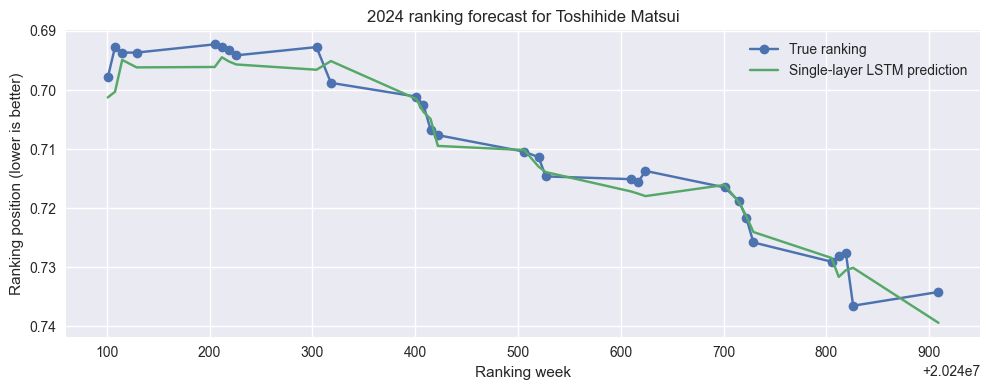

In [19]:
model_results(0)

### Reading The Results
- **Per-player MAE table**: each row compares true vs predicted 2024 rankings for a single player/model combo. Values are already in raw ranking points (lower MAE means tighter forecasts). The stacked LSTM is slightly better on average (≈0.0248) but the single-layer model wins for several players.
- **Global MAE summary**: calculates a single error score over every 2024 sequence; here the global single-layer LSTM leads with ≈0.0059, so it becomes the model used for the plot.
- **Forecast plot**: shows the best global model on one representative player. Circles are the official rankings, crosses are the one-step-ahead predictions. Because rankings are “lower is better,” the y-axis is inverted so upward moves indicate worse performance. Parallel trajectories imply the model is tracking the 2024 swings reasonably closely.
